### Imports and Device Setup, Path Configuration and Label Parsing Logic

In [12]:
import os
import json
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision import models
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, accuracy_score
from torchvision.models import resnet50, ResNet50_Weights


# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [13]:
DATA_ROOT = "/kaggle/input/datasets/blossom1994/bdd-small-dataset/input"

TRAIN_LABEL_PATH = os.path.join(DATA_ROOT, "annotation", "trainlabels.json")
VAL_LABEL_PATH   = os.path.join(DATA_ROOT, "annotation", "vallabels.json")
TEST_LABEL_PATH  = os.path.join(DATA_ROOT, 'annotation', 'testlabels.json')


TRAIN_DIR = os.path.join(DATA_ROOT, "bdd100k_image", "train")
VAL_DIR   = os.path.join(DATA_ROOT, "bdd100k_image", "val")
TEST_DIR  = os.path.join(DATA_ROOT, 'bdd100k_image', 'test')


In [14]:
def load_sequence_labels(json_path, seq_length=5):
    with open(json_path, 'r') as f:
        data = json.load(f)

    label_map = {}
    for seq_name, frames in data.items():
        seq_binary = [0, 0, 0]
        # Only label from frames the model actually sees
        for frame_id in sorted(frames.keys())[:seq_length]:
            labels = frames[frame_id]
            if labels[0] == 1: seq_binary[0] = 1  # red
            if labels[2] == 1: seq_binary[1] = 1  # green
            if labels[4] == 1: seq_binary[2] = 1  # sign
        label_map[seq_name] = seq_binary
    return label_map

train_labels = load_sequence_labels(TRAIN_LABEL_PATH, seq_length=5)
val_labels   = load_sequence_labels(VAL_LABEL_PATH,   seq_length=5)
print(f'Loaded {len(train_labels)} train and {len(val_labels)} val sequences.')

Loaded 1360 train and 276 val sequences.


### Sequence Discovery

In [15]:
def get_sequence_paths(root_dir):
    # Finds all subfolders (sequences) containing .jpg images
    sequences = [os.path.join(root_dir, d) for d in os.listdir(root_dir)
                 if os.path.isdir(os.path.join(root_dir, d))]
    return sorted(sequences)

train_sequences = get_sequence_paths(TRAIN_DIR)
val_sequences = get_sequence_paths(VAL_DIR)

print(f"Found {len(train_sequences)} training sequences and {len(val_sequences)} validation sequences.")

Found 1360 training sequences and 276 validation sequences.


### Dataset Class
This class loads a sequence of images and stacks them into a single tensor.

In [16]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

class TrafficSequenceDataset(Dataset):
    def __init__(self, sequence_paths, labels_dict, seq_length=5, transform=None):
        self.seq_length  = seq_length
        self.labels_dict = labels_dict
        self.transform   = transform
        self.sequence_paths = [
            p for p in sequence_paths
            if os.path.basename(p) in labels_dict
        ]

    def __len__(self):
        return len(self.sequence_paths)

    def __getitem__(self, idx):
        seq_path = self.sequence_paths[idx]
        seq_name = os.path.basename(seq_path)

        img_files = sorted(glob.glob(os.path.join(seq_path, '*.jpg')))[:self.seq_length]

        frames = []
        for img_path in img_files:
            img = Image.open(img_path).convert('RGB')
            if self.transform:
                img = self.transform(img)
            frames.append(img)

        # Pad with zeros if fewer than seq_length frames
        while len(frames) < self.seq_length:
            frames.append(torch.zeros_like(frames[0]))

        label = torch.tensor(self.labels_dict[seq_name], dtype=torch.float32)
        return torch.stack(frames), label


train_sequences = get_sequence_paths(TRAIN_DIR)
val_sequences   = get_sequence_paths(VAL_DIR)

train_dataset = TrafficSequenceDataset(train_sequences, train_labels, transform=train_transform)
val_dataset   = TrafficSequenceDataset(val_sequences,   val_labels,   transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False, num_workers=2)

print(f'Train: {len(train_dataset)} sequences | Val: {len(val_dataset)} sequences')


Train: 1360 sequences | Val: 276 sequences


### GRU Model Architecture

In [17]:
class GRUTrafficClassifier(nn.Module):
    def __init__(self, hidden_dim=256, num_layers=2, num_classes=3, dropout=0.5):
        super().__init__()

        backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

        # Freeze all ResNet layers first
        for param in backbone.parameters():
            param.requires_grad = False

        # Unfreeze layer3 and layer4
        for param in backbone.layer3.parameters():
            param.requires_grad = True
        for param in backbone.layer4.parameters():
            param.requires_grad = True

        self.feature_extractor = nn.Sequential(*list(backbone.children())[:-1])
        self.backbone = backbone  # keep ref for optimizer param groups

        self.gru = nn.GRU(
            input_size=2048,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        B, T, C, H, W = x.shape
        x = x.view(B * T, C, H, W)
        features = self.feature_extractor(x)
        features = torch.flatten(features, 1)
        features = features.view(B, T, -1)
        gru_out, _ = self.gru(features)
        return self.fc(self.dropout(gru_out[:, -1, :]))


model = GRUTrafficClassifier(hidden_dim=256, num_layers=2, dropout=0.5).to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params:     {total_params:,}')
print(f'Trainable params: {trainable_params:,}')


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 197MB/s]


Total params:     27,756,075
Trainable params: 24,262,147


### Training Setup and Training Loop

In [18]:
# Weighted loss for class imbalance: Red ~20%, Green ~26%, Sign ~59%
pos_weight = torch.tensor([4.0, 2.8, 1.0]).to(device)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# AdamW with discriminative learning rates:
# pretrained layers get 10x smaller LR to adapt gently
optimizer = torch.optim.AdamW([
    {'params': model.backbone.layer3.parameters(), 'lr': 1e-4},
    {'params': model.backbone.layer4.parameters(), 'lr': 1e-4},
    {'params': model.gru.parameters(),             'lr': 1e-3},
    {'params': model.fc.parameters(),              'lr': 1e-3},
], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.5)
epochs    = 30


In [19]:
def train_model(patience=7):
    best_f1    = 0.0
    best_epoch = 0
    no_improve = 0

    for epoch in range(epochs):
        # ── Training ──────────────────────────────────────────────────
        model.train()
        train_loss = 0
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            loss = criterion(model(data), target)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        scheduler.step()

        # ── Validation ────────────────────────────────────────────────
        model.eval()
        val_loss   = 0
        all_preds, all_targets = [], []

        with torch.no_grad():
            for data, target in val_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                val_loss += criterion(output, target).item()
                preds = (torch.sigmoid(output) > 0.5).float()
                all_preds.append(preds.cpu().numpy())
                all_targets.append(target.cpu().numpy())

        all_preds   = np.vstack(all_preds)
        all_targets = np.vstack(all_targets)

        # Average per-label accuracy
        avg_acc = np.mean([
            accuracy_score(all_targets[:, i], all_preds[:, i])
            for i in range(all_targets.shape[1])
        ])
        f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0)
        current_lr = scheduler.get_last_lr()[0]

        print(
            f'Epoch {epoch+1:2d}/{epochs} | '
            f'Train Loss: {train_loss/len(train_loader):.4f} | '
            f'Val Loss: {val_loss/len(val_loader):.4f} | '
            f'Val Avg Acc: {avg_acc:.4f} | '
            f'Val F1 (macro): {f1:.4f} | '
            f'LR: {current_lr:.6f}'
        )

        # ── Checkpoint ────────────────────────────────────────────────
        if f1 > best_f1:
            best_f1    = f1
            best_epoch = epoch + 1
            no_improve = 0
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_f1': best_f1,
            }, 'best_model.pth')
            print(f'  -> Best model saved (F1: {best_f1:.4f})')
        else:
            no_improve += 1
            print(f'  -> No improvement. Patience: {no_improve}/{patience}')
            if no_improve >= patience:
                print(f'\nEarly stopping at epoch {epoch+1}')
                break

    print(f'\nBest model: epoch {best_epoch} | Val F1: {best_f1:.4f}')
    model.load_state_dict(torch.load('best_model.pth')['model_state_dict'])

train_model()


Epoch  1/30 | Train Loss: 0.9765 | Val Loss: 1.0618 | Val Avg Acc: 0.4722 | Val F1 (macro): 0.6244 | LR: 0.000100
  -> Best model saved (F1: 0.6244)
Epoch  2/30 | Train Loss: 0.9670 | Val Loss: 1.0460 | Val Avg Acc: 0.4722 | Val F1 (macro): 0.6244 | LR: 0.000100
  -> No improvement. Patience: 1/7
Epoch  3/30 | Train Loss: 0.8996 | Val Loss: 1.4110 | Val Avg Acc: 0.6812 | Val F1 (macro): 0.4365 | LR: 0.000100
  -> No improvement. Patience: 2/7
Epoch  4/30 | Train Loss: 0.8628 | Val Loss: 1.1574 | Val Avg Acc: 0.6703 | Val F1 (macro): 0.6166 | LR: 0.000100
  -> No improvement. Patience: 3/7
Epoch  5/30 | Train Loss: 0.8265 | Val Loss: 1.3172 | Val Avg Acc: 0.7017 | Val F1 (macro): 0.6311 | LR: 0.000100
  -> Best model saved (F1: 0.6311)
Epoch  6/30 | Train Loss: 0.8063 | Val Loss: 0.8745 | Val Avg Acc: 0.6775 | Val F1 (macro): 0.7038 | LR: 0.000100
  -> Best model saved (F1: 0.7038)
Epoch  7/30 | Train Loss: 0.7657 | Val Loss: 0.8853 | Val Avg Acc: 0.6027 | Val F1 (macro): 0.6797 | LR: 0

### Testing

TEST RESULTS
  Red Light    Accuracy: 0.8324
  Green Light  Accuracy: 0.7045
  Road Sign    Accuracy: 0.8000

  Avg Label Accuracy : 0.7790
  Exact Match Acc    : 0.4631
  Macro F1           : 0.7463

              precision    recall  f1-score   support

   Red Light       0.89      0.66      0.76       219
 Green Light       0.65      0.55      0.59       218
   Road Sign       0.80      1.00      0.89       444

   micro avg       0.78      0.80      0.79       881
   macro avg       0.78      0.74      0.75       881
weighted avg       0.78      0.80      0.78       881
 samples avg       0.78      0.74      0.74       881



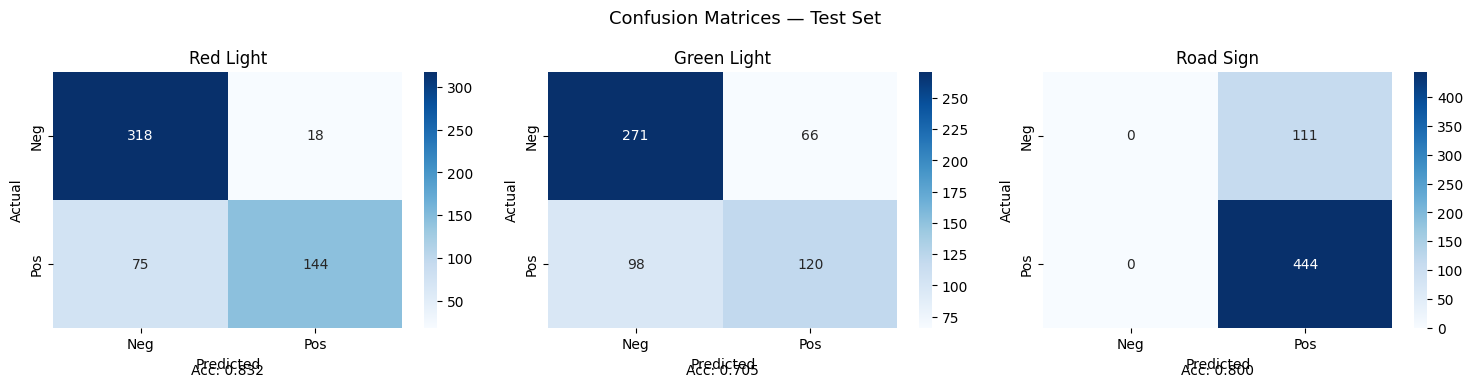

In [23]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import seaborn as sns
def test_model():
    # Load test dataset (no augmentation)
    test_labels  = load_sequence_labels(TEST_LABEL_PATH, seq_length=5)
    test_sequences = get_sequence_paths(TEST_DIR)
    test_dataset = TrafficSequenceDataset(test_sequences, test_labels, transform=val_transform)
    test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2)

    model.eval()
    all_preds, all_targets = [], []

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            preds = (torch.sigmoid(model(data)) > 0.5).float()
            all_preds.append(preds.cpu().numpy())
            all_targets.append(target.cpu().numpy())

    all_preds   = np.vstack(all_preds)
    all_targets = np.vstack(all_targets)
    class_names = ['Red Light', 'Green Light', 'Road Sign']

    print('=' * 55)
    print('TEST RESULTS')
    print('=' * 55)

    # Per-label accuracy
    for i, name in enumerate(class_names):
        acc = accuracy_score(all_targets[:, i], all_preds[:, i])
        print(f'  {name:12s} Accuracy: {acc:.4f}')

    avg_acc     = np.mean([accuracy_score(all_targets[:, i], all_preds[:, i]) for i in range(3)])
    exact_match = (all_preds == all_targets).all(axis=1).mean()
    f1_mac      = f1_score(all_targets, all_preds, average='macro', zero_division=0)

    print(f'\n  Avg Label Accuracy : {avg_acc:.4f}')
    print(f'  Exact Match Acc    : {exact_match:.4f}')
    print(f'  Macro F1           : {f1_mac:.4f}')

    print('\n' + classification_report(all_targets, all_preds, target_names=class_names, zero_division=0))

    # Confusion matrix per class
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for i, name in enumerate(class_names):
        cm = confusion_matrix(all_targets[:, i], all_preds[:, i])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                    xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'])
        axes[i].set_title(f'{name}')
        axes[i].set_xlabel('Predicted')
        axes[i].set_ylabel('Actual')
        acc = accuracy_score(all_targets[:, i], all_preds[:, i])
        axes[i].text(0.5, -0.18, f'Acc: {acc:.3f}', transform=axes[i].transAxes,
                     ha='center', fontsize=10)
    plt.suptitle('Confusion Matrices — Test Set', fontsize=13)
    plt.tight_layout()
    plt.show()

test_model()


### inference and visualization

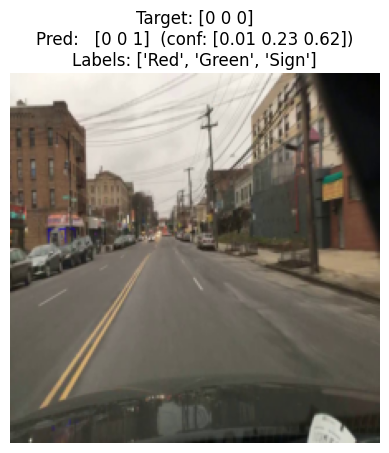

In [24]:
def predict_sequence(dataset_idx):
    model.eval()
    with torch.no_grad():
        frames, label = val_dataset[dataset_idx]
        input_tensor = frames.unsqueeze(0).to(device)
        output = model(input_tensor)
        prediction = torch.sigmoid(output).cpu().numpy()[0]

    # Denormalize: undo ImageNet mean/std
    mean = torch.tensor([0.485, 0.456, 0.406])
    std  = torch.tensor([0.229, 0.224, 0.225])
    frame = frames[0] * std[:, None, None] + mean[:, None, None]
    frame = frame.permute(1, 2, 0).clamp(0, 1).numpy()

    label_names = ["Red", "Green", "Sign"]
    pred_binary = (prediction > 0.5).astype(int)

    plt.imshow(frame)
    plt.title(
        f"Target: {label.numpy().astype(int)}\n"
        f"Pred:   {pred_binary}  (conf: {np.round(prediction, 2)})\n"
        f"Labels: {label_names}"
    )
    plt.axis('off')
    plt.show()

predict_sequence(0)